# Lab 2
---
### Name: Mohammed Feras Sawab

### ID: 2240009066
---

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def sample_image(image, factor):
    height, width = image.shape[0], image.shape[1]
    return cv2.resize(image, (height//factor, width//factor), interpolation=cv2.INTER_NEAREST)

In [3]:
def quantize_image(image, levels):
    return np.floor(image / (256 // levels)) * (256//levels)

In [4]:
def plot_image(original, sampled, quantized):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(original, cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(sampled, cmap='gray')
    ax[1].set_title('Sampled Image')
    ax[1].axis('off')

    ax[2].imshow(quantized, cmap='gray')
    ax[2].set_title('Quantized Image')
    ax[2].axis('off')

    plt.show()

In [5]:
import pathlib
image_path = pathlib.Path(r"../lab1/images/lena_gray_256.tif")

In [6]:
sampling_factor=14
quantization_levels=9

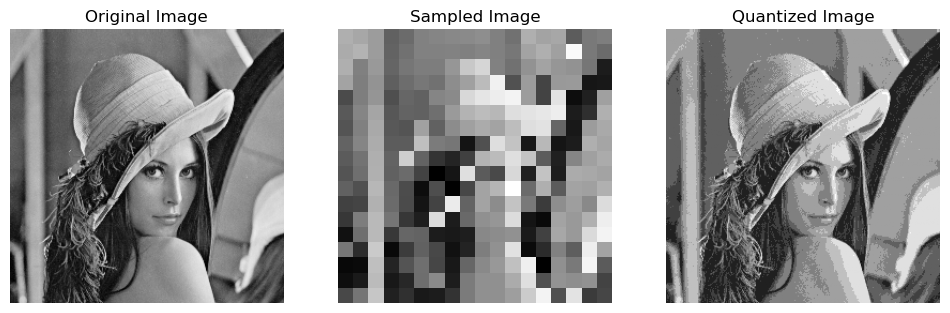

In [7]:
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_image(original_image, sampled_image, quantized_image)

In [8]:
from PIL import Image

img1=Image.open('../lab1/images/lena_gray_256.tif')
img2=Image.open ('../lab1/images/cameraman.tif')

resize=(400,400)

img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr

resultImage=Image.fromarray(addition)
resultImage.show()

In [9]:
img3 = Image.open('../lab1/images/lena_gray_256.tif')
img3.show()

img4 = Image.open('../lab1/images/cameraman.tif')
img4.show()

resize = (400,400)

img3 = img3.resize(resize,Image.Resampling.LANCZOS)
img4 = img4.resize(resize,Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr|im3arr

resultImage2 = Image.fromarray(union)
resultImage2.show()

### Task 1: Change the sampling and quantization parameters and observe the effects

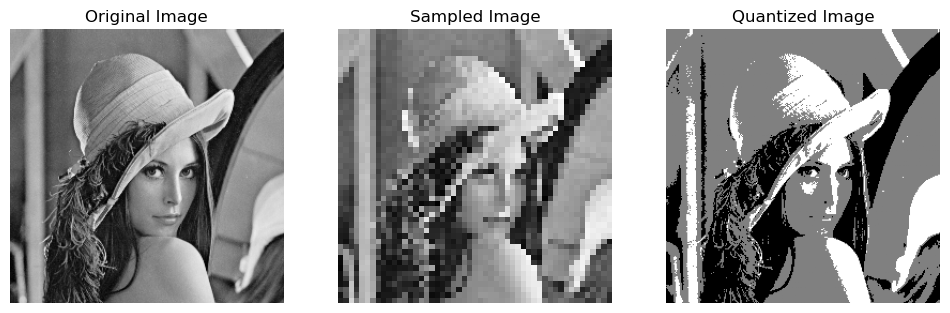

In [10]:
quant = 3
sampling = 5
q = quantize_image(original_image, quant)
s = sample_image(original_image, sampling)

plot_image(original_image, s, q)

### Task 2: Read two images, convert them into arrays, and perform the following operations on them.

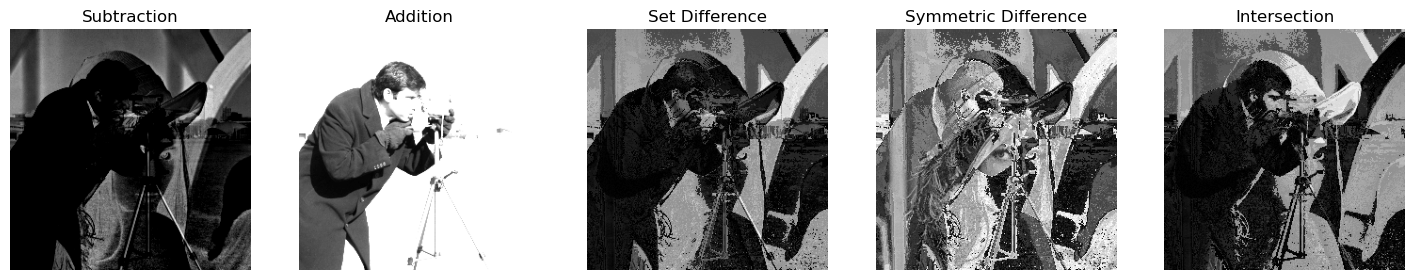

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

camera = cv2.imread(r'../lab1/images/cameraman.tif', cv2.IMREAD_GRAYSCALE)
lena = cv2.imread(r'../lab1/images/lena_gray_256.tif', cv2.IMREAD_GRAYSCALE)

camera = cv2.resize(camera, (256, 256))
lena = cv2.resize(lena, (256, 256))

camera = np.array(camera)
lena = np.array(lena)

sub_ = cv2.subtract(camera, lena)
add_ = cv2.add(camera, np.ones_like(camera) * 175)
set_diff = cv2.bitwise_and(camera, cv2.bitwise_not(lena))
symm_diff = cv2.bitwise_xor(camera, lena)
inter = cv2.bitwise_and(camera, lena)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))

ax[0].imshow(sub_, cmap='gray')
ax[0].set_title("Subtraction")

ax[1].imshow(add_, cmap='gray')
ax[1].set_title("Addition")

ax[2].imshow(set_diff, cmap='gray')
ax[2].set_title("Set Difference")

ax[3].imshow(symm_diff, cmap='gray')
ax[3].set_title("Symmetric Difference")

ax[4].imshow(inter, cmap='gray')
ax[4].set_title("Intersection")

for a in ax:
    a.axis('off')

plt.show()